How Much Embedding Dimension Do We Really Need? A Cross-Dataset Study of Semantic Resolution in Dense Retrieval
> Does lower dimension reduce accuracy? ❌

> Does every retrieval dataset require the same semantic resolution? ✅

>Is there a critical embedding dimension below which retrieval quality collapses? ✅

## Contribution1

> Critical Semantic Dimension (CSD):  
*The smallest embedding dimension that preserves X% of the full embedding's performance.*

If:

* **768 → Recall@10 = 0.80**

and we choose a threshold of **95%**, then:

* **0.95 × 0.80 = 0.76**

The **first embedding dimension** that achieves:

* **Recall@10 ≥ 0.76**

is called the **Critical Semantic Dimension (CSD)**.


---
## Contribution2

> Semantic Collapse Curve:

Instead of using a table:

768
512
256
...
we plot a curve instead. *italicized text* *italicized text*

---
## Contribution 3

> Cross-domain comparison:

For example:

SciFact may have a CSD of 256.
Quora may have a CSD of 64.
FiQA may have a CSD of 512.

This naturally leads to the question: Why?

---
The goal is no longer adaptive embeddings.Instead, the focus is to collect results across multiple datasets.

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
# !pip uninstall -y numpy scipy scikit-learn sentence-transformers > /dev/null 2>&1
# !pip install numpy==2.2.6 scipy==1.16.0 scikit-learn==1.7.1 sentence-transformers > /dev/null 2>&1
# !pip install beir > /dev/null 2>&1

In [3]:
DATASETS = [
    "scifact",
    "nfcorpus",
    "fiqa",
    "arguana",
    "quora",
    # "dbpedia-entity",
    # "trec-covid",
]

In [4]:
from beir.datasets.data_loader import GenericDataLoader
from beir import util

def load_dataset(dataset):

    url = f"https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/{dataset}.zip"

    data_path = util.download_and_unzip(
        url,
        "./datasets"
    )

    corpus, queries, qrels = GenericDataLoader(data_path).load(split="test")

    return corpus, queries, qrels

In [5]:
import numpy
import scipy
import sklearn

print(numpy.__version__)
print(scipy.__version__)
print(sklearn.__version__)

2.2.6
1.16.0
1.7.1


In [6]:
import numpy as np
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [7]:
def evaluate_dataset(dataset):

    corpus, queries, qrels = load_dataset(dataset)

    corpus_ids = list(corpus.keys())
    corpus_texts = [
        corpus[d]["title"] + " " + corpus[d]["text"]
        for d in corpus_ids
    ]

    query_ids = list(queries.keys())
    query_texts = [queries[q] for q in query_ids]

    print(f"\nEncoding {dataset}")

    corpus_embeddings = model.encode(
        corpus_texts,
        convert_to_numpy=True,
        normalize_embeddings=True,
        batch_size=64,
        show_progress_bar=True
    )

    query_embeddings = model.encode(
        query_texts,
        convert_to_numpy=True,
        normalize_embeddings=True,
        batch_size=64,
        show_progress_bar=True
    )

    dims = [768, 512, 256, 128, 64, 32]

    recalls = {}

    # Process queries in batches to reduce memory usage.
    query_batch_size = 64

    for dim in dims:

        print(f"\nEvaluating dimension {dim}")

        c = corpus_embeddings[:, :dim].copy()
        q = query_embeddings[:, :dim].copy()

        # Re-normalize after truncating the embeddings.
        c /= np.linalg.norm(c, axis=1, keepdims=True)
        q /= np.linalg.norm(q, axis=1, keepdims=True)

        recall = 0

        for start in range(0, len(query_ids), query_batch_size):

            end = min(start + query_batch_size, len(query_ids))

            q_batch = q[start:end]

            # Compute similarity scores for the current batch.
            scores = q_batch @ c.T

            for i in range(scores.shape[0]):

                qid = query_ids[start + i]

                ranked = np.argsort(-scores[i])[:10]

                retrieved = {corpus_ids[j] for j in ranked}

                relevant = set(qrels[qid].keys())

                if len(retrieved & relevant):
                    recall += 1

            # Free memory before processing the next batch.
            del scores

        recall /= len(query_ids)

        recalls[dim] = recall

        print(dataset, dim, recall)

    return recalls

In [8]:
results={}

for d in DATASETS:

    results[d]=evaluate_dataset(d)

./datasets/scifact.zip:   0%|          | 0.00/2.69M [00:00<?, ?iB/s]

  0%|          | 0/5183 [00:00<?, ?it/s]


Encoding scifact


Batches:   0%|          | 0/81 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

...

  0%|          | 0/522931 [00:00<?, ?it/s]


Encoding quora


Batches:   0%|          | 0/8171 [00:00<?, ?it/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]


Evaluating dimension 768
quora 768 0.974

Evaluating dimension 512
quora 512 0.9737

Evaluating dimension 256
quora 256 0.9709

Evaluating dimension 128
quora 128 0.968

Evaluating dimension 64
quora 64 0.957

Evaluating dimension 32
quora 32 0.9239


In [9]:
print("\n")

for dataset in DATASETS:

    print(dataset)

    for dim,score in results[dataset].items():

        print(dim,round(score,4))

    print()



scifact
768 0.8033
512 0.7933
256 0.7567
128 0.7233
64 0.65
32 0.5067

nfcorpus
768 0.7059
512 0.6904
256 0.6687
128 0.6409
64 0.5666
32 0.4923

fiqa
768 0.7824
512 0.7793
256 0.75
128 0.7052
64 0.608
32 0.4228

arguana
768 0.7304
512 0.7205
256 0.7084
128 0.6899
64 0.6216
32 0.5057

quora
768 0.974
512 0.9737
256 0.9709
128 0.968
64 0.957
32 0.9239



In [10]:
THRESHOLD = 0.95

print(f"{'Dataset':<15} {'CSD':<6} {'Full Recall':<12}")

for dataset in results:

    full = results[dataset][768]
    target = THRESHOLD * full

    csd = None

    # smallest dimension that still preserves 95%
    for dim in sorted(results[dataset].keys()):
        if results[dataset][dim] >= target:
            csd = dim
            break

    print(f"{dataset:<15} {csd:<6} {full:.4f}")

Dataset         CSD    Full Recall 
scifact         512    0.8033
nfcorpus        512    0.7059
fiqa            256    0.7824
arguana         256    0.7304
quora           64     0.9740


In [11]:
import pandas as pd

rows = []

for dataset in results:

    full = results[dataset][768]

    for dim, score in results[dataset].items():

        rows.append({
            "Dataset": dataset,
            "Dimension": dim,
            "Recall@10": score,
            "Retention": score / full
        })

df = pd.DataFrame(rows)

df

,Dataset,Dimension,Recall@10,Retention
0,scifact,768,0.803333,1.000000
1,scifact,512,0.793333,0.987552
2,scifact,256,0.756667,0.941909
3,scifact,128,0.723333,0.900415
4,scifact,64,0.650000,0.809129
5,scifact,32,0.506667,0.630705
6,nfcorpus,768,0.705882,1.000000
7,nfcorpus,512,0.690402,0.978070
8,nfcorpus,256,0.668731,0.947368
9,nfcorpus,128,0.640867,0.907895


In [12]:
import pandas as pd

summary = []

for dataset in DATASETS:

    corpus, queries, qrels = load_dataset(dataset)

    avg_query_len = sum(len(q.split()) for q in queries.values()) / len(queries)

    avg_relevant = sum(len(v) for v in qrels.values()) / len(qrels)

    summary.append({
        "Dataset": dataset,
        "CSD": next(
            dim for dim in sorted(results[dataset].keys())
            if results[dataset][dim] >= 0.95 * results[dataset][768]
        ),
        "Recall768": results[dataset][768],
        "AvgQueryLen": avg_query_len,
        "AvgRelevantDocs": avg_relevant,
    })

summary = pd.DataFrame(summary)

summary

  0%|          | 0/5183 [00:00<?, ?it/s]

  0%|          | 0/3633 [00:00<?, ?it/s]

  0%|          | 0/57638 [00:00<?, ?it/s]

  0%|          | 0/8674 [00:00<?, ?it/s]

  0%|          | 0/522931 [00:00<?, ?it/s]

,Dataset,CSD,Recall768,AvgQueryLen,AvgRelevantDocs
0,scifact,512,0.803333,12.506667,1.130000
1,nfcorpus,512,0.705882,3.294118,38.185759
2,fiqa,256,0.782407,10.939815,2.632716
3,arguana,256,0.730441,193.553343,1.000000
4,quora,64,0.974000,9.531000,1.567500


In [13]:
summary.corr(numeric_only=True)

,CSD,Recall768,AvgQueryLen,AvgRelevantDocs
CSD,1.000000,-0.697864,-0.196999,0.549609
Recall768,-0.697864,1.000000,-0.347690,-0.492842
AvgQueryLen,-0.196999,-0.347690,1.000000,-0.308427
AvgRelevantDocs,0.549609,-0.492842,-0.308427,1.000000


In [14]:
dims = [768, 512, 256, 128, 64, 32]

required_dim = {}

# Load the dataset and generate normalized embeddings.
corpus, queries, qrels = load_dataset("scifact")

corpus_ids = list(corpus.keys())
corpus_texts = [
    corpus[d]["title"] + " " + corpus[d]["text"]
    for d in corpus_ids
]

query_ids = list(queries.keys())
query_texts = [queries[q] for q in query_ids]

corpus_embeddings = model.encode(
    corpus_texts,
    convert_to_numpy=True,
    normalize_embeddings=True,
    batch_size=64,
    show_progress_bar=True
)

query_embeddings = model.encode(
    query_texts,
    convert_to_numpy=True,
    normalize_embeddings=True,
    batch_size=64,
    show_progress_bar=True
)

# Find the smallest embedding dimension that still retrieves
# at least one relevant document in the top 10.
for q_idx, qid in enumerate(query_ids):

    relevant = set(qrels[qid].keys())

    req = None

    for dim in sorted(dims):

        c = corpus_embeddings[:, :dim]
        q = query_embeddings[q_idx, :dim]

        c = c / np.linalg.norm(c, axis=1, keepdims=True)
        q = q / np.linalg.norm(q)

        scores = c @ q

        top10 = np.argpartition(-scores, 10)[:10]

        retrieved = {corpus_ids[i] for i in top10}

        if len(retrieved & relevant) > 0:
            req = dim
            break

    if req is None:
        req = 768

    required_dim[qid] = req

print("Done /")

  0%|          | 0/5183 [00:00<?, ?it/s]

Batches:   0%|          | 0/81 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Done.


In [15]:
from collections import Counter

dist = Counter(required_dim.values())

for d in sorted(dist):
    print(f"{d:>4} : {dist[d]}")

  32 : 152
  64 : 48
 128 : 28
 256 : 12
 512 : 8
 768 : 52


In [16]:
import pandas as pd

query_df = pd.DataFrame({
    "QueryID": list(required_dim.keys()),
    "RequiredDim": list(required_dim.values()),
    "Query": [queries[q] for q in required_dim.keys()]
})

query_df.head()

,QueryID,RequiredDim,Query
0,1,256,0-dimensional biomaterials show inductive prop...
1,3,64,"1,000 genomes project enables mapping of genet..."
2,5,64,1/2000 in UK have abnormal PrP positivity.
3,13,64,5% of perinatal mortality is due to low birth ...
4,36,32,A deficiency of vitamin B12 increases blood le...


> Semantic Neighborhood Stability Across Embedding Dimensions

In [17]:
!pip install scipy > /dev/null 2>&1

In [18]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, kendalltau

dims = [768, 512, 256, 128, 64, 32]

# Load the dataset and compute normalized embeddings.
corpus, queries, qrels = load_dataset("scifact")

corpus_ids = list(corpus.keys())
corpus_texts = [
    corpus[d]["title"] + " " + corpus[d]["text"]
    for d in corpus_ids
]

query_ids = list(queries.keys())
query_texts = [queries[q] for q in query_ids]

print("Encoding...")

corpus_embeddings = model.encode(
    corpus_texts,
    convert_to_numpy=True,
    normalize_embeddings=True,
    batch_size=64,
    show_progress_bar=True
)

query_embeddings = model.encode(
    query_texts,
    convert_to_numpy=True,
    normalize_embeddings=True,
    batch_size=64,
    show_progress_bar=True
)

# Use the full 768-dimensional ranking as the reference.
scores768 = query_embeddings @ corpus_embeddings.T

reference_rankings = []

TOPK = 100

for i in range(len(query_ids)):
    ranking = np.argsort(-scores768[i])[:TOPK]
    reference_rankings.append(ranking)

results = []

for dim in dims:

    print(f"Evaluating {dim}")

    c = corpus_embeddings[:, :dim]
    q = query_embeddings[:, :dim]

    c /= np.linalg.norm(c, axis=1, keepdims=True)
    q /= np.linalg.norm(q, axis=1, keepdims=True)

    scores = q @ c.T

    spearman_scores = []
    kendall_scores = []

    for i in range(len(query_ids)):

        ref = reference_rankings[i]

        new = np.argsort(-scores[i])[:TOPK]

        # Map each retrieved document to its position in the new ranking.
        pos = {doc: rank for rank, doc in enumerate(new)}

        ref_rank = np.arange(TOPK)

        new_rank = [
            pos.get(doc, TOPK)
            for doc in ref
        ]

        sp, _ = spearmanr(ref_rank, new_rank)
        kt, _ = kendalltau(ref_rank, new_rank)

        spearman_scores.append(sp)
        kendall_scores.append(kt)

    results.append({
        "Dimension": dim,
        "Spearman": np.nanmean(spearman_scores),
        "KendallTau": np.nanmean(kendall_scores)
    })

results = pd.DataFrame(results)

results

  0%|          | 0/5183 [00:00<?, ?it/s]

Encoding...


Batches:   0%|          | 0/81 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Evaluating 768
Evaluating 512
Evaluating 256
Evaluating 128
Evaluating 64
Evaluating 32


,Dimension,Spearman,KendallTau
0,768,1.000000,1.000000
1,512,0.859641,0.699766
2,256,0.687166,0.529435
3,128,0.538273,0.408165
4,64,0.418077,0.318551
5,32,0.284604,0.220841


In [19]:
import numpy as np
import pandas as pd

BLOCK = 32

records = []

for start in range(0, 768, BLOCK):

    end = start + BLOCK

    print(f"Block {start}:{end}")

    C = corpus_embeddings[:, start:end].copy()
    Q = query_embeddings[:, start:end].copy()

    C /= np.linalg.norm(C, axis=1, keepdims=True)
    Q /= np.linalg.norm(Q, axis=1, keepdims=True)

    scores = Q @ C.T

    recall = 0

    for i, qid in enumerate(query_ids):

        top10 = np.argsort(-scores[i])[:10]

        retrieved = {corpus_ids[j] for j in top10}

        relevant = set(qrels[qid].keys())

        if len(retrieved & relevant):
            recall += 1

    recall /= len(query_ids)

    records.append([start, end, recall])

block_df = pd.DataFrame(
    records,
    columns=["Start", "End", "Recall@10"]
)

block_df

Block 0:32
Block 32:64
Block 64:96
Block 96:128
Block 128:160
Block 160:192
Block 192:224
Block 224:256
Block 256:288
Block 288:320
Block 320:352
Block 352:384
Block 384:416
Block 416:448
Block 448:480
Block 480:512
Block 512:544
Block 544:576
Block 576:608
Block 608:640
Block 640:672
Block 672:704
Block 704:736
Block 736:768


,Start,End,Recall@10
0,0,32,0.506667
1,32,64,0.510000
2,64,96,0.486667
3,96,128,0.500000
4,128,160,0.530000
5,160,192,0.483333
6,192,224,0.530000
7,224,256,0.506667
8,256,288,0.526667
9,288,320,0.523333


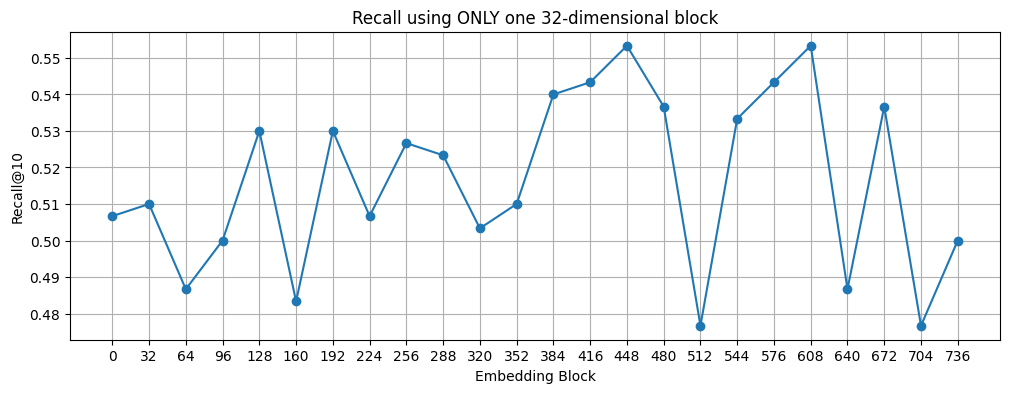

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.plot(
    block_df["Start"],
    block_df["Recall@10"],
    marker="o"
)

plt.xticks(block_df["Start"])

plt.xlabel("Embedding Block")
plt.ylabel("Recall@10")
plt.title("Recall using ONLY one 32-dimensional block")

plt.grid(True)

plt.show()

In [21]:
import numpy as np
import pandas as pd

dims = [32, 64, 128, 256, 512, 768]

rows = []

scores768 = query_embeddings @ corpus_embeddings.T

for i, qid in enumerate(query_ids):

    full_scores = scores768[i]

    # Compute the gap between the top two retrieval scores.
    top2 = np.sort(full_scores)[-2:]
    margin = top2[1] - top2[0]

    # Measure the uncertainty of the score distribution.
    p = np.exp(full_scores - full_scores.max())
    p /= p.sum()

    entropy = -(p * np.log(p + 1e-12)).sum()

    # Measure how spread out the scores are.
    variance = np.var(full_scores)

    # Basic query statistics.
    qlen = len(queries[qid].split())
    n_rel = len(qrels[qid])

    # Find the smallest dimension that preserves the
    # same retrieval outcome as the full embedding.
    required = 768

    relevant = set(qrels[qid].keys())

    full_recall = None

    for dim in dims[::-1]:

        C = corpus_embeddings[:, :dim]
        Q = query_embeddings[:, :dim]

        C = C / np.linalg.norm(C, axis=1, keepdims=True)
        q = Q[i:i+1]
        q = q / np.linalg.norm(q, axis=1, keepdims=True)

        s = (q @ C.T)[0]

        top10 = np.argsort(-s)[:10]

        retrieved = {corpus_ids[j] for j in top10}

        recall = int(len(retrieved & relevant) > 0)

        if dim == 768:
            full_recall = recall

        if recall == full_recall:
            required = dim
        else:
            break

    rows.append([
        qid,
        required,
        qlen,
        n_rel,
        margin,
        entropy,
        variance
    ])

features = pd.DataFrame(rows, columns=[
    "QueryID",
    "RequiredDim",
    "QueryLength",
    "RelevantDocs",
    "Margin",
    "Entropy",
    "Variance"
])

features.head()

,QueryID,RequiredDim,QueryLength,RelevantDocs,Margin,Entropy,Variance
0,1,32,5,1,0.125241,8.513594,0.074043
1,3,64,20,1,0.005100,8.459528,0.153371
2,5,512,7,1,0.152264,8.510519,0.080938
3,13,128,10,1,0.107190,8.472151,0.127220
4,36,32,10,2,0.007184,8.471874,0.126508


In [22]:
features.corr(numeric_only=True)["RequiredDim"].sort_values()

,RequiredDim
Margin,-0.166194
Variance,-0.067477
QueryLength,-0.006791
RelevantDocs,0.021923
Entropy,0.123770
RequiredDim,1.000000


In [23]:
import numpy as np
import pandas as pd

effective_rank = []

for emb in query_embeddings:

    x = emb.copy()

    x = x / np.linalg.norm(x)

    num = (np.sum(x**2))**2
    den = np.sum(x**4)

    pr = num / den

    effective_rank.append(pr)

effective_rank = np.array(effective_rank)

In [24]:
analysis = query_df.copy()
analysis["EffectiveRank"] = effective_rank

analysis.head()

,QueryID,RequiredDim,Query,EffectiveRank
0,1,256,0-dimensional biomaterials show inductive prop...,73.232033
1,3,64,"1,000 genomes project enables mapping of genet...",78.850418
2,5,64,1/2000 in UK have abnormal PrP positivity.,66.970016
3,13,64,5% of perinatal mortality is due to low birth ...,81.759315
4,36,32,A deficiency of vitamin B12 increases blood le...,84.749580


In [25]:
from scipy.stats import spearmanr

corr, p = spearmanr(
    analysis["EffectiveRank"],
    analysis["RequiredDim"]
)

print("Spearman =",corr)
print("p-value =",p)

Spearman = -0.0925334740453401
p-value = 0.10971636362587975


In [26]:
analysis.groupby("RequiredDim")["EffectiveRank"].mean()

,EffectiveRank
RequiredDim,
32,80.579590
64,81.590256
128,80.177551
256,80.383766
512,74.770203
768,75.141975


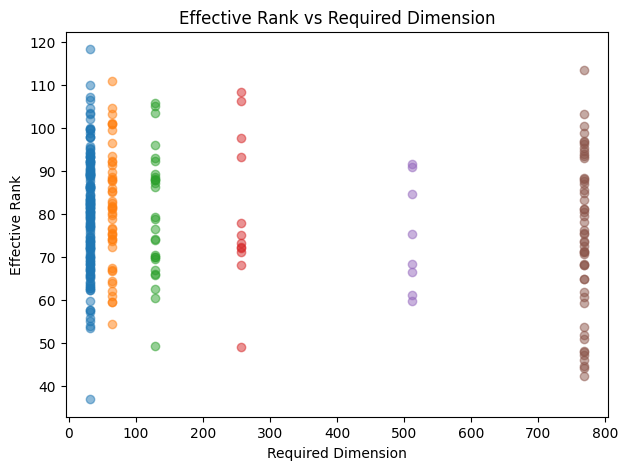

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

for d in sorted(analysis.RequiredDim.unique()):

    vals = analysis[
        analysis.RequiredDim==d
    ]["EffectiveRank"]

    plt.scatter(
        [d]*len(vals),
        vals,
        alpha=.5
    )

plt.xlabel("Required Dimension")
plt.ylabel("Effective Rank")
plt.title("Effective Rank vs Required Dimension")

plt.show()

In [28]:
from scipy.stats import spearmanr
import pandas as pd
import numpy as np

print("Computing full similarity matrix...")

scores = query_embeddings @ corpus_embeddings.T

dims = [768, 512, 256, 128, 64, 32]

rows = []

for i, qid in enumerate(query_ids):

    relevant = set(qrels[qid].keys())

    # Use the top-2 score gap as a difficulty estimate.
    order = np.argsort(-scores[i])

    top_scores = scores[i][order]

    margin = float(top_scores[0] - top_scores[1])

    # Find the smallest dimension that still retrieves
    # a relevant document in the top 10.
    required_dim = 768

    for dim in reversed(dims):

        q = query_embeddings[i:i+1, :dim]
        c = corpus_embeddings[:, :dim]

        q = q / np.linalg.norm(q, axis=1, keepdims=True)
        c = c / np.linalg.norm(c, axis=1, keepdims=True)

        s = (q @ c.T)[0]

        ranked = np.argsort(-s)[:10]

        retrieved = {corpus_ids[j] for j in ranked}

        if len(retrieved & relevant):

            required_dim = dim

            break

    rows.append({
        "Margin": margin,
        "RequiredDim": required_dim
    })

df = pd.DataFrame(rows)

print(df.head())

corr, p = spearmanr(df["Margin"], df["RequiredDim"])

print()
print("Spearman =", corr)
print("p-value  =", p)

print()
print(df.groupby("RequiredDim")["Margin"].mean())

Computing full similarity matrix...
     Margin  RequiredDim
0  0.125241          768
1  0.005100           64
2  0.152264          512
3  0.107190           64
4  0.007184           32

Spearman = -0.5131824184823507
p-value  = 1.4846012405911218e-21

RequiredDim
32     0.350622
64     0.156447
128    0.073819
256    0.123706
512    0.189695
768    0.082741
Name: Margin, dtype: float64


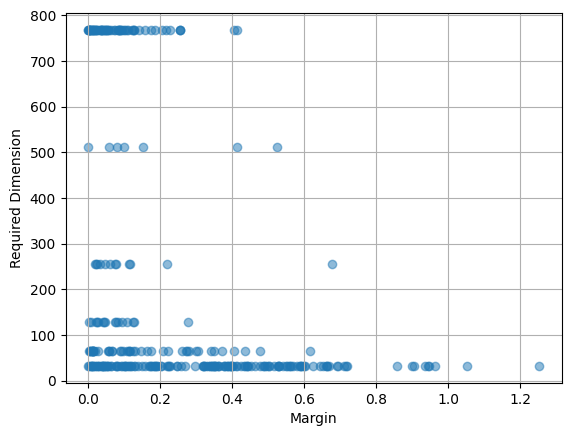

In [29]:
plt.scatter(df["Margin"], df["RequiredDim"], alpha=0.5)
plt.xlabel("Margin")
plt.ylabel("Required Dimension")
plt.grid(True)
plt.show()

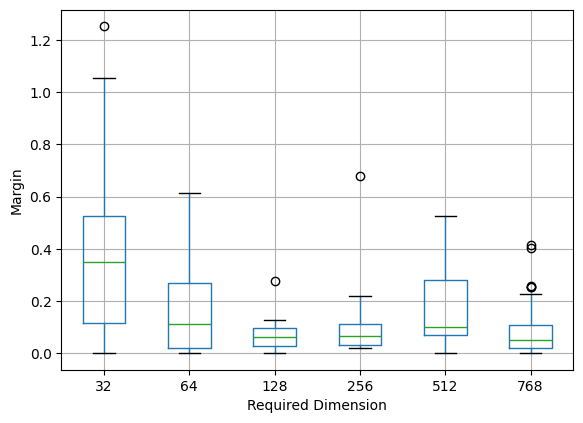

In [30]:
import matplotlib.pyplot as plt

df.boxplot(column="Margin", by="RequiredDim")

plt.title("")
plt.suptitle("")
plt.xlabel("Required Dimension")
plt.ylabel("Margin")
plt.show()

In [31]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Input features used to predict the required embedding dimension.
predictor_columns = [
    "Margin",
    "Entropy",
    "Variance",
    "QueryLength",
    "RelevantDocs"
]

X = features[predictor_columns]
y = features["RequiredDim"]

# Split the data into training and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Train the classifier.
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)

# Evaluate the model.
pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print()

print(classification_report(y_test, pred))

# Show which features contribute the most.
importance = pd.DataFrame({
    "Feature": predictor_columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print("\nFeature Importance")
print(importance)

Accuracy: 0.6777777777777778

              precision    recall  f1-score   support

          32       0.71      0.94      0.81        63
          64       0.33      0.14      0.20        14
         128       0.00      0.00      0.00         5
         256       0.00      0.00      0.00         4
         512       0.00      0.00      0.00         2
         768       0.00      0.00      0.00         2

    accuracy                           0.68        90
   macro avg       0.17      0.18      0.17        90
weighted avg       0.55      0.68      0.60        90


Feature Importance
        Feature  Importance
0        Margin    0.306659
1       Entropy    0.253430
2      Variance    0.244502
3   QueryLength    0.175386
4  RelevantDocs    0.020024


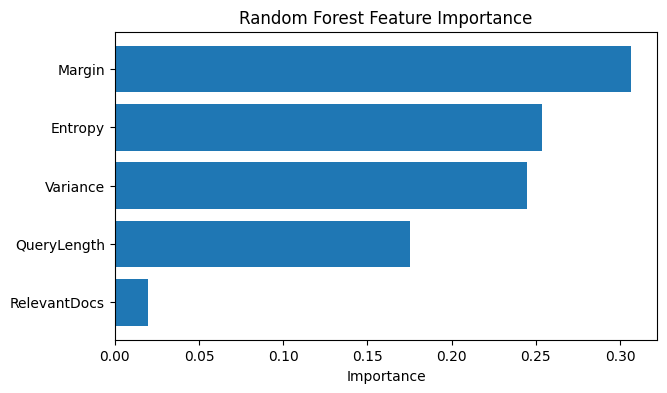

In [32]:
import matplotlib.pyplot as plt

importance = importance.sort_values("Importance")

plt.figure(figsize=(7,4))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")

plt.show()

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.6888888888888889
              precision    recall  f1-score   support

          32       0.70      0.98      0.82        63
          64       0.00      0.00      0.00        14
         128       0.00      0.00      0.00         5
         256       0.00      0.00      0.00         4
         512       0.00      0.00      0.00         2
         768       0.00      0.00      0.00         2

    accuracy                           0.69        90
   macro avg       0.12      0.16      0.14        90
weighted avg       0.49      0.69      0.57        90



In [34]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

smote = SMOTE(random_state=42, k_neighbors=2)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_bal, y_train_bal)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.4888888888888889
              precision    recall  f1-score   support

          32       0.69      0.57      0.63        63
          64       0.26      0.36      0.30        14
         128       0.29      0.40      0.33         5
         256       0.00      0.00      0.00         4
         512       0.00      0.00      0.00         2
         768       1.00      0.50      0.67         2

    accuracy                           0.49        90
   macro avg       0.37      0.30      0.32        90
weighted avg       0.56      0.49      0.52        90



In [35]:
from collections import Counter

print(Counter(y))

Counter({32: 211, 64: 45, 128: 18, 256: 13, 512: 8, 768: 5})


In [36]:
print(df["RequiredDim"].value_counts().sort_index())

RequiredDim
32     152
64      45
128     16
256     12
512      7
768     68
Name: count, dtype: int64


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  0%|          | 0/5183 [00:00<?, ?it/s]

Encoding corpus...


Batches:   0%|          | 0/81 [00:00<?, ?it/s]

Encoding queries...


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Computing full ranking...
Dimension 768
Dimension 512
Dimension 256
Dimension 128
Dimension 64
Dimension 32


,Dimension,Mean Rank Shift,Median Rank Shift,Recall@10
0,768,0.000000,0.0,0.803333
1,512,7.336667,0.0,0.793333
2,256,22.870000,0.0,0.756667
3,128,52.540000,1.0,0.723333
4,64,111.623333,2.0,0.650000
5,32,285.943333,7.0,0.506667


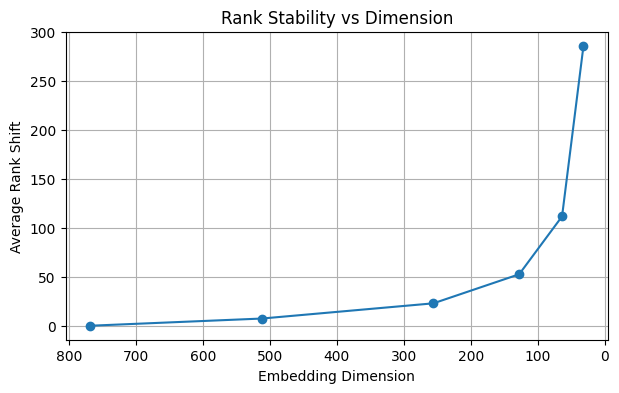

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sentence_transformers import SentenceTransformer

# Load the embedding model.
model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

# Load the dataset and generate embeddings.
corpus, queries, qrels = load_dataset("scifact")

corpus_ids = list(corpus.keys())
query_ids = list(queries.keys())

corpus_texts = [
    corpus[c]["title"] + " " + corpus[c]["text"]
    for c in corpus_ids
]

query_texts = [queries[q] for q in query_ids]

print("Encoding corpus...")
corpus_emb = model.encode(
    corpus_texts,
    convert_to_numpy=True,
    normalize_embeddings=True,
    batch_size=64,
    show_progress_bar=True
)

print("Encoding queries...")
query_emb = model.encode(
    query_texts,
    convert_to_numpy=True,
    normalize_embeddings=True,
    batch_size=64,
    show_progress_bar=True
)

# Use the full embedding as the reference ranking.
print("Computing full ranking...")

full_scores = query_emb @ corpus_emb.T
full_rank = np.argsort(-full_scores, axis=1)

dims = [768, 512, 256, 128, 64, 32]

records = []

for dim in dims:

    print("Dimension", dim)

    c = corpus_emb[:, :dim]
    q = query_emb[:, :dim]

    c /= np.linalg.norm(c, axis=1, keepdims=True)
    q /= np.linalg.norm(q, axis=1, keepdims=True)

    scores = q @ c.T
    rank = np.argsort(-scores, axis=1)

    correlations = []
    success = []

    for i, qid in enumerate(query_ids):

        relevant = list(qrels[qid].keys())

        if len(relevant) == 0:
            continue

        doc = relevant[0]

        if doc not in corpus:
            continue

        idx = corpus_ids.index(doc)

        r_full = np.where(full_rank[i] == idx)[0][0]
        r_dim = np.where(rank[i] == idx)[0][0]

        # Measure how much the relevant document moves in the ranking.
        correlations.append(abs(r_dim - r_full))

        retrieved = set(corpus_ids[j] for j in rank[i, :10])

        success.append(int(len(retrieved & set(relevant)) > 0))

    records.append({
        "Dimension": dim,
        "Mean Rank Shift": np.mean(correlations),
        "Median Rank Shift": np.median(correlations),
        "Recall@10": np.mean(success)
    })

df = pd.DataFrame(records)

display(df)

plt.figure(figsize=(7, 4))
plt.plot(df["Dimension"], df["Mean Rank Shift"], marker="o")
plt.gca().invert_xaxis()
plt.xlabel("Embedding Dimension")
plt.ylabel("Average Rank Shift")
plt.title("Rank Stability vs Dimension")
plt.grid(True)
plt.show()

In [38]:
features.head()

,QueryID,RequiredDim,QueryLength,RelevantDocs,Margin,Entropy,Variance
0,1,32,5,1,0.125241,8.513594,0.074043
1,3,64,20,1,0.005100,8.459528,0.153371
2,5,512,7,1,0.152264,8.510519,0.080938
3,13,128,10,1,0.107190,8.472151,0.127220
4,36,32,10,2,0.007184,8.471874,0.126508


In [39]:
%whos DataFrame

Variable      Type         Data/Info
------------------------------------
X             DataFrame           Margin   Entropy  <...>n\n[300 rows x 5 columns]
X_test        DataFrame           Margin   Entropy  <...>\n\n[90 rows x 5 columns]
X_train       DataFrame           Margin   Entropy  <...>n\n[210 rows x 5 columns]
X_train_bal   DataFrame           Margin   Entropy  <...>n\n[888 rows x 5 columns]
analysis      DataFrame        QueryID  RequiredDim <...>n\n[300 rows x 4 columns]
block_df      DataFrame        Start  End  Recall@10<...>23    736  768   0.500000
df            DataFrame       Dimension  Mean Rank S<...>           7.0   0.506667
features      DataFrame        QueryID  RequiredDim <...>n\n[300 rows x 7 columns]
importance    DataFrame            Feature  Importan<...>       Margin    0.306659
query_df      DataFrame        QueryID  RequiredDim <...>n\n[300 rows x 3 columns]
results       DataFrame       Dimension  Spearman  K<...> 32  0.284604    0.220841
summary      

In [40]:
%whos ndarray

Variable            Type       Data/Info
----------------------------------------
C                   ndarray    5183x32: 165856 elems, type `float32`, 663424 bytes (647.875 kb)
Q                   ndarray    300x32: 9600 elems, type `float32`, 38400 bytes
c                   ndarray    5183x32: 165856 elems, type `float32`, 663424 bytes (647.875 kb)
corpus_emb          ndarray    5183x768: 3980544 elems, type `float32`, 15922176 bytes (15.1845703125 Mb)
corpus_embeddings   ndarray    5183x768: 3980544 elems, type `float32`, 15922176 bytes (15.1845703125 Mb)
effective_rank      ndarray    300: 300 elems, type `float32`, 1200 bytes
emb                 ndarray    768: 768 elems, type `float32`, 3072 bytes
full_rank           ndarray    300x5183: 1554900 elems, type `int64`, 12439200 bytes (11.862945556640625 Mb)
full_scores         ndarray    300x5183: 1554900 elems, type `float32`, 6219600 bytes (5.9314727783203125 Mb)
new                 ndarray    100: 100 elems, type `int64`, 800 byt

In [42]:
import numpy as np

# Re-calculate rank768 (full dimension)
# Assuming corpus_embeddings and query_embeddings are available from previous cells.
# From the Kernel State, corpus_embeddings and query_embeddings are available.
scores768 = query_embeddings @ corpus_embeddings.T
rank768 = np.argsort(-scores768, axis=1)

# Re-calculate rank32 (32 dimensions)
dim_32 = 32
c_32 = corpus_embeddings[:, :dim_32]
q_32 = query_embeddings[:, :dim_32]

c_32 /= np.linalg.norm(c_32, axis=1, keepdims=True)
q_32 /= np.linalg.norm(q_32, axis=1, keepdims=True)

scores32 = q_32 @ c_32.T
rank32 = np.argsort(-scores32, axis=1)

rank_shift = []

for i, qid in enumerate(query_ids):


    relevant_docs = list(qrels[qid].keys())

    if len(relevant_docs) == 0:
        rank_shift.append(np.nan)
        continue

    doc = relevant_docs[0]


    if doc not in corpus_ids:
        rank_shift.append(np.nan)
        continue

    doc_idx = corpus_ids.index(doc)


    r768 = np.where(rank768[i] == doc_idx)[0][0]


    r32 = np.where(rank32[i] == doc_idx)[0][0]

    rank_shift.append(abs(r32 - r768))

print("Computed:", len(rank_shift))

Computed: 300


In [43]:
from scipy.stats import spearmanr

analysis = features.copy()
analysis["RankShift"] = rank_shift

display(analysis.head())

print()

for col in ["Margin","Entropy","Variance","QueryLength","RelevantDocs"]:

    rho,p = spearmanr(analysis[col], analysis["RankShift"])

    print(f"{col:15s}  rho={rho:.3f}   p={p:.3e}")

,QueryID,RequiredDim,QueryLength,RelevantDocs,Margin,Entropy,Variance,RankShift
0,1,32,5,1,0.125241,8.513594,0.074043,3624
1,3,64,20,1,0.005100,8.459528,0.153371,66
2,5,512,7,1,0.152264,8.510519,0.080938,161
3,13,128,10,1,0.107190,8.472151,0.127220,3
4,36,32,10,2,0.007184,8.471874,0.126508,1



Margin           rho=-0.537   p=9.232e-24
Entropy          rho=0.150   p=9.407e-03
Variance         rho=-0.025   p=6.713e-01
QueryLength      rho=-0.153   p=7.798e-03
RelevantDocs     rho=0.054   p=3.507e-01


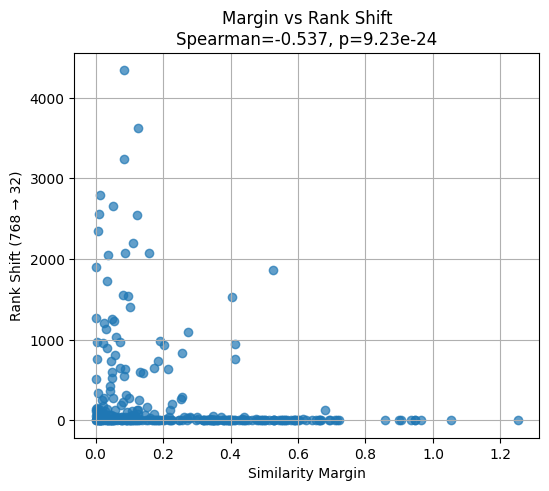

In [44]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

rho, p = spearmanr(analysis["Margin"], analysis["RankShift"])

plt.figure(figsize=(6,5))

plt.scatter(
    analysis["Margin"],
    analysis["RankShift"],
    alpha=0.7
)

plt.xlabel("Similarity Margin")
plt.ylabel("Rank Shift (768 → 32)")
plt.title(f"Margin vs Rank Shift\nSpearman={rho:.3f}, p={p:.2e}")

plt.grid(True)

plt.show()

In [45]:
from scipy.stats import spearmanr
import pandas as pd

features_to_test = [
    "Margin",
    "Entropy",
    "Variance",
    "QueryLength",
    "RelevantDocs"
]

rows = []

for feature in features_to_test:
    rho, p = spearmanr(
        analysis[feature],
        analysis["RankShift"]
    )

    rows.append({
        "Feature": feature,
        "Spearman": rho,
        "p-value": p
    })

summary_table = pd.DataFrame(rows)

summary_table = summary_table.sort_values(
    by="Spearman",
    key=lambda s: abs(s),
    ascending=False
)

summary_table

,Feature,Spearman,p-value
0,Margin,-0.536509,9.231572e-24
3,QueryLength,-0.153346,7.797713e-03
1,Entropy,0.149711,9.407139e-03
4,RelevantDocs,0.054067,3.506988e-01
2,Variance,-0.024603,6.712581e-01


Plot saved


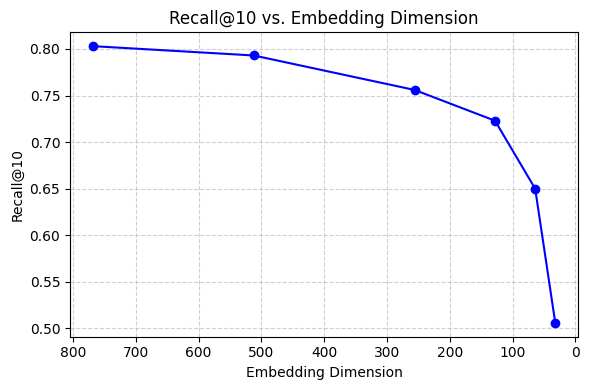

In [46]:
import matplotlib.pyplot as plt

dims = [768, 512, 256, 128, 64, 32]
recall = [0.803, 0.793, 0.756, 0.723, 0.650, 0.506]

plt.figure(figsize=(6, 4))
plt.plot(dims, recall, marker='o', linestyle='-', color='b')
plt.xlabel('Embedding Dimension')
plt.ylabel('Recall@10')
plt.title('Recall@10 vs. Embedding Dimension')
plt.grid(True, linestyle='--', alpha=0.6)
plt.gca().invert_xaxis()  # Because dimensions are decreasing
plt.tight_layout()
print("Plot saved")